# Week 5 — Credit Risk Scoring Pipeline
## EDA and Feature Engineering

**Business:** A bank loses money every time it approves a loan that defaults. This pipeline scores every applicant on credit risk, loan propensity, and customer value — with SHAP explainability for every decision.

**Dataset:** LendingClub — 421MB — real loan application data

**Goal:** EDA, understand patterns, engineer features for credit risk, propensity, and RFM models

**Author:** Martin James Ng'ang'a | github.com/M20Jay

## Section 1 - Import Libraries


In [4]:
# Importing all tools needed for EDA AND feature engineering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## Section 2 - Load Dataset

In [5]:
# Loading the LendingClub dataset and take a first look at its shape, columns and data types
df = pd.read_csv('/Users/martinjames/Documents/GitHub/credit-risk-scoring-pipeline/data/loan/loan.csv', low_memory=False)
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Shape: (887379, 74)

First 5 rows:
        id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  1077501    1296599     5000.0       5000.0           4975.0   36 months   
1  1077430    1314167     2500.0       2500.0           2500.0   60 months   
2  1077175    1313524     2400.0       2400.0           2400.0   36 months   
3  1076863    1277178    10000.0      10000.0          10000.0   36 months   
4  1075358    1311748     3000.0       3000.0           3000.0   60 months   

   int_rate  installment grade sub_grade  ... total_bal_il il_util  \
0     10.65       162.87     B        B2  ...          NaN     NaN   
1     15.27        59.83     C        C4  ...          NaN     NaN   
2     15.96        84.33     C        C5  ...          NaN     NaN   
3     13.49       339.31     C        C1  ...          NaN     NaN   
4     12.69        67.79     B        B5  ...          NaN     NaN   

  open_rv_12m  open_rv_24m max_bal_bc all_util total_rev_hi_lim inq_fi  \
0

## Section 3 - Data Inspection

In [6]:
# Checking data types, missing values and basic statistics to understand what cleaning is needed
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing ===")
print(df.isnull().sum())

# Missing values percentage
missing = df.isnull().sum()
missing_pct = (missing/len(df)*100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage':missing_pct
})
# Show only columns that have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values("Missing Percentage", ascending=False)

print("=== Columns with Missing Values ===")
print(missing_df)

print("\n=== Basic Statistics ===")
print(df.describe())

=== Data Types ===
id                    int64
member_id             int64
loan_amnt           float64
funded_amnt         float64
funded_amnt_inv     float64
                     ...   
all_util            float64
total_rev_hi_lim    float64
inq_fi              float64
total_cu_tl         float64
inq_last_12m        float64
Length: 74, dtype: object

=== Missing ===
id                       0
member_id                0
loan_amnt                0
funded_amnt              0
funded_amnt_inv          0
                     ...  
all_util            866007
total_rev_hi_lim     70276
inq_fi              866007
total_cu_tl         866007
inq_last_12m        866007
Length: 74, dtype: int64
=== Columns with Missing Values ===
                             Missing Count  Missing Percentage
dti_joint                           886870               99.94
annual_inc_joint                    886868               99.94
verification_status_joint           886868               99.94
il_util             

## Section 4 - Target Variable Analysis

In [9]:
# Identifying the loan_status column — this is what we are predicting.
# A loan is either Fully Paid or Charged Off (defaulted).

# Check all column names
print(df.columns.tolist())

print("\n=== Loan Status Distribution ===")
print(df['loan_status'].value_counts)

print("\n=== Loan Status Percentage ===")
print(df['loan_status'].value_counts(normalize=True).round(3)*100)

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il

## Section 5 - Filter Target Variable

In [13]:
# We keep only Fully Paid and Charged Off loans
# These are the only loans with a known final outcome

df_model = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Convert to binary target
df_model['default'] = (df_model['loan_status'] == 'Charged Off').astype(int)

print(df_model.shape)

print("\n=== Default Distribution ===")
print(df_model['default'].value_counts())

print("\n=== Default Rate ===")
print(df_model['default'].value_counts(normalize=True).round(3)*100)


# Save filtered dataset as Parquet for faster future loading
df_model.to_parquet('/Users/martinjames/Documents/GitHub/credit-risk-scoring-pipeline/data/loan/loan_filtered.parquet', index=False)
print("\nParquet file saved ✅")

# Checking if parquet was saved
import os
size = os.path.getsize('/Users/martinjames/Documents/GitHub/credit-risk-scoring-pipeline/data/loan/loan_filtered.parquet')
print(f"Parquet file size: {size / 1024 / 1024:.1f} MB")

# Check available columns before feature engineering
print("\n=== Available Columns in df_model ===")
for col in df_model.columns:
    print(col)

(252971, 75)

=== Default Distribution ===
default
0    207723
1     45248
Name: count, dtype: int64

=== Default Rate ===
default
0    82.1
1    17.9
Name: proportion, dtype: float64

Parquet file saved ✅
Parquet file size: 36.3 MB

=== Available Columns in df_model ===
id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_join

## Section 6 - Feature Engineering

In [16]:
# Creating new features that help the model identify defaulters more accurately
# Feature 1 — Clean DTI (debt to income ratio)
# Values above 100 are data errors — capping them
df_model['dti_clean'] = df_model['dti'].clip(upper=100)

# Feature 2 — Credit history in years
# earliest_cr_line is a date — convert to years of credit history
df_model['issue_d'] = pd.to_datetime(df_model['issue_d'], format ='%b-%Y')
df_model['earliest_cr_line'] = pd.to_datetime(df_model['earliest_cr_line'], format='%b-%Y')
df_model['credit_history_years'] = ((df_model['issue_d'] - df_model['earliest_cr_line']).dt.days/365).round(1)

# Feature 3 — Loan to income ratio
# How large is the loan relative to what they earn?

df_model['loan_to_income'] = (df_model['loan_amnt']/df_model['annual_inc']).round(4)

print("New features created ✅")
print(df_model[['dti_clean', 'credit_history_years', 'loan_to_income']].head(10))


New features created ✅
    dti_clean  credit_history_years  loan_to_income
0       27.65                  26.9          0.2083
1        1.00                  12.7          0.0833
2        8.72                  10.1          0.1959
3       20.00                  15.8          0.2033
5       11.20                   7.1          0.1389
7        5.35                   4.9          0.0625
8        5.55                   7.7          0.1400
9       18.08                   7.3          0.3583
10      16.12                  13.9          0.0903
11      10.78                  22.2          0.1600


## Section 7 - Visualisations

In [17]:
# Visualising default patterns across key features to identify which borrowers are highest risk

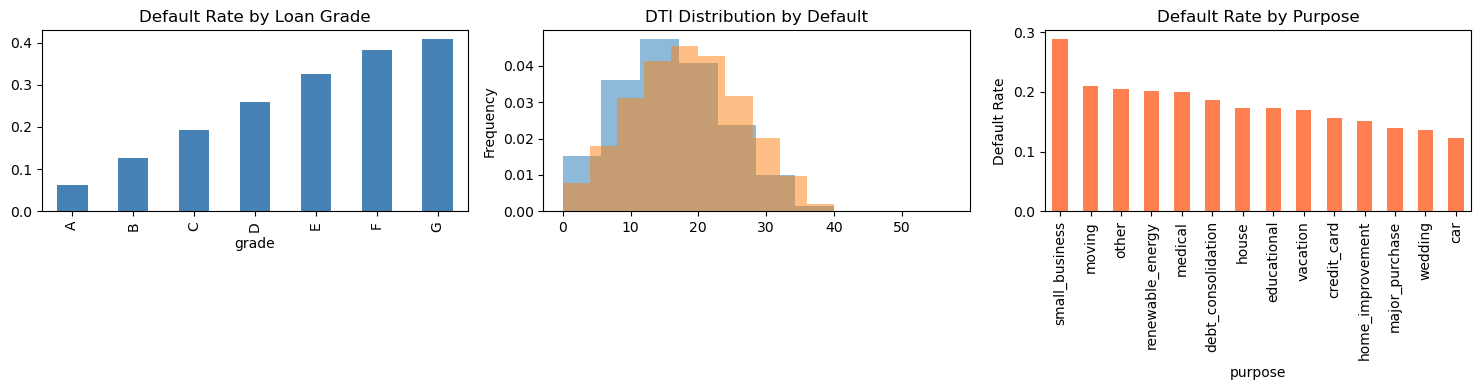

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Default rate by grade
df_model.groupby('grade')['default'].mean().plot(
    kind='bar', ax=axes[0], title='Default Rate by Loan Grade', color='steelblue')

# Plot 2 — DTI distribution by default
df_model[df_model['default']==0]['dti_clean'].plot(kind='hist', alpha=0.5, ax=axes[1], label=' No Default', density=True)
df_model[df_model['default']==1]['dti_clean'].plot(kind='hist', alpha=0.5, ax=axes[1], label='Default', density=True)
axes[1].set_title('DTI Distribution by Default')
axes[1].legend

# Plot 3 — Default rate by loan purpose
df_model.groupby('purpose')['default'].mean().sort_values(
    ascending=False).plot(kind='bar', ax=axes[2],title='Default Rate by Purpose', color='coral')
axes[2].set_ylabel('Default Rate')

plt.tight_layout()
plt.savefig(
    '../screenshots/day1_eda_charts.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## Section 8 - Key Findings Summary

In [27]:
# Business insights from Day 1 EDA
print("=" * 55)
print("Key Findings — Day 1 EDA")
print("=" * 55)
print(f"Total dataset: 887,379 loans")
print(f"Modelling dataset: 252,971 loans")
print(f"Default rate: 17.9%")
print(f"Class imbalance: 82% paid vs 18% defaulted")
print(f"Strongest predictor: loan grade")
print(f"DTI: useful but weak standalone")
print(f"Purpose: meaningful categorical feature")
print(f"New features created: dti_clean, credit_history_years, loan_to_income")
print(f"File saved: loan_filtered.parquet — 36MB vs 421MB CSV")
print("=" * 55)
print("Next: Day 2 — XGBoost model + probability calibration")

Key Findings — Day 1 EDA
Total dataset: 887,379 loans
Modelling dataset: 252,971 loans
Default rate: 17.9%
Class imbalance: 82% paid vs 18% defaulted
Strongest predictor: loan grade
DTI: useful but weak standalone
Purpose: meaningful categorical feature
New features created: dti_clean, credit_history_years, loan_to_income
File saved: loan_filtered.parquet — 36MB vs 421MB CSV
Next: Day 2 — XGBoost model + probability calibration
